# AURN Air Quality Imputation — IJC319 Digital Artefact

**Title:** Evaluating Traditional, Machine Learning, and Generative AI-Based Methods for Imputing Missing Values in AURN Air Quality Data for Greater London

**Author:** Tun Muhammad Hariz Bin Tun Mahadi | University of Sheffield | Registration: 230190355

**Supervisor:** Asra Aslam

---

## Pipeline Overview

This notebook implements the full imputation benchmarking pipeline described in the dissertation:

1. **Data Loading & Preprocessing** — Load raw AURN data, clean and create ground-truth dataset
2. **Exploratory Data Analysis** — Descriptive statistics and inter-pollutant correlation analysis
3. **Artificial Missingness Simulation** — Introduce MNAR-like missingness using `mdatagen`
4. **Imputation Methods** — Apply six methods: Mean, KNN, Regression, Random Forest, Autoencoder, GAIN
5. **Evaluation** — Compute RMSE, MAE, R² across all method–pollutant combinations
6. **Results Visualisation** — Heatmaps, scatter plots, error distributions, boxplots, radar chart

> **Dataset:** Greater London AURN monitoring station, hourly measurements, full year 2024
> Source: [UK Air Quality Data Portal](https://www.get-air-pollution-data.service.gov.uk)


## Step 0 — Import Libraries

All required libraries are imported here. Run this cell first before executing any other section.

In [1]:
!pip install mdatagen
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

## Step 1 — Data Loading & Preprocessing

**Corresponds to:** Dissertation Section 3.1, Step 1

Raw AURN hourly data is loaded from `Greater_London.csv`. Non-numeric values are coerced to NaN, and the dataset is inspected for pre-existing missingness. Rows with any missing values are dropped to create a clean **ground-truth dataset** used as the evaluation benchmark throughout.


In [3]:
df = pd.read_csv("Greater_London.csv")

df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

for col in df.columns:
    if col not in ['Date', 'Time']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Missing % by column:")
print(df.isna().mean() * 100)

Missing % by column:
Date                 0.000000
Time                 0.000000
Nitrogen dioxide     6.420765
Ozone                6.557377
PM10                 6.022313
PM2.5                6.022313
Sulphur dioxide     15.960838
dtype: float64


### 1.1 Raw Dataset — Missing Values Before Cleaning

In [4]:
df.describe()

,Date,Nitrogen dioxide,Ozone,PM10,PM2.5,Sulphur dioxide
count,8784,8220.000000,8208.000000,8255.000000,8255.000000,7382.000000
mean,2024-07-01 12:00:00,22.530951,51.020348,12.406908,7.328952,0.789713
min,2024-01-01 00:00:00,2.819320,-0.049890,0.575000,0.377000,0.000000
25%,2024-04-01 00:00:00,12.856578,37.369480,7.350000,3.939000,0.390500
50%,2024-07-01 12:00:00,19.862925,51.688630,10.450000,5.613000,0.658635
75%,2024-10-01 00:00:00,29.392963,64.211650,15.175000,8.632000,1.049890
max,2024-12-31 00:00:00,97.629860,159.506320,56.500000,46.533000,47.273770
std,NaN,12.623911,21.136587,7.710527,5.615071,0.776068


### 1.2 Drop Rows with Missing Values → Ground-Truth Dataset

In [5]:
df = df.dropna().reset_index(drop=True)

numeric_cols = df.select_dtypes(include=[np.number]).columns
data = df[numeric_cols]

print("Missing % by column:")
print(data.isna().mean() * 100)

Missing % by column:
Nitrogen dioxide    0.0
Ozone               0.0
PM10                0.0
PM2.5               0.0
Sulphur dioxide     0.0
dtype: float64


### 1.3 Ground-Truth Dataset — Descriptive Statistics (Table 1 in dissertation)

In [6]:
df.describe()

,Date,Nitrogen dioxide,Ozone,PM10,PM2.5,Sulphur dioxide
count,7315,7315.000000,7315.000000,7315.000000,7315.000000,7315.000000
mean,2024-06-06 09:12:10.827067904,22.274450,52.113464,12.605434,7.431128,0.788481
min,2024-01-02 00:00:00,2.819320,-0.049890,0.800000,0.519000,0.000000
25%,2024-03-20 00:00:00,12.607325,38.966040,7.475000,3.962000,0.389910
50%,2024-06-05 00:00:00,19.536680,52.686480,10.600000,5.660000,0.658400
75%,2024-08-24 00:00:00,29.038685,65.134660,15.350000,8.703000,1.047870
max,2024-11-12 00:00:00,97.629860,159.506320,56.500000,46.533000,47.273770
std,NaN,12.597202,20.719594,7.834597,5.739484,0.777889


## Step 2 — Exploratory Data Analysis

**Corresponds to:** Dissertation Section 3.1, Inter-Pollutant Correlation Analysis

Before introducing missingness, the correlation structure of the five pollutants is characterised using Pearson correlation. This directly informs method selection rationale and the interpretation of differential performance across pollutants in Section 5.2.


### 2.1 Descriptive Statistics Table

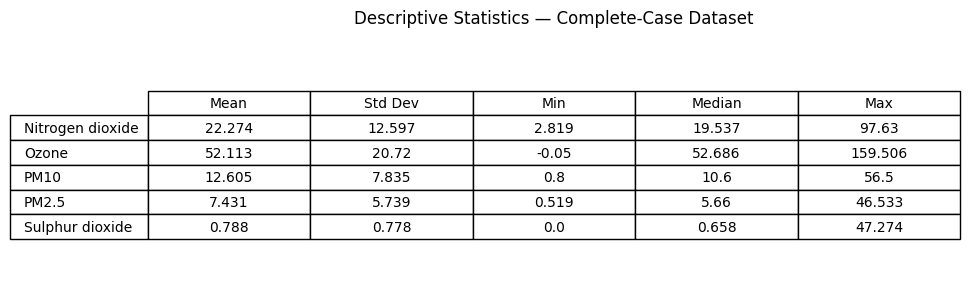

In [7]:
desc = data.describe().T[['mean','std','min','50%','max']]
desc.columns = ['Mean', 'Std Dev', 'Min', 'Median', 'Max']
desc = desc.round(3)

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
tbl = ax.table(cellText=desc.values, rowLabels=desc.index,
               colLabels=desc.columns, cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.5)
plt.title("Descriptive Statistics — Complete-Case Dataset", fontsize=12, pad=20)
plt.tight_layout()
plt.show()

### 2.2 Pearson Correlation Matrix (Figure 3 in dissertation)

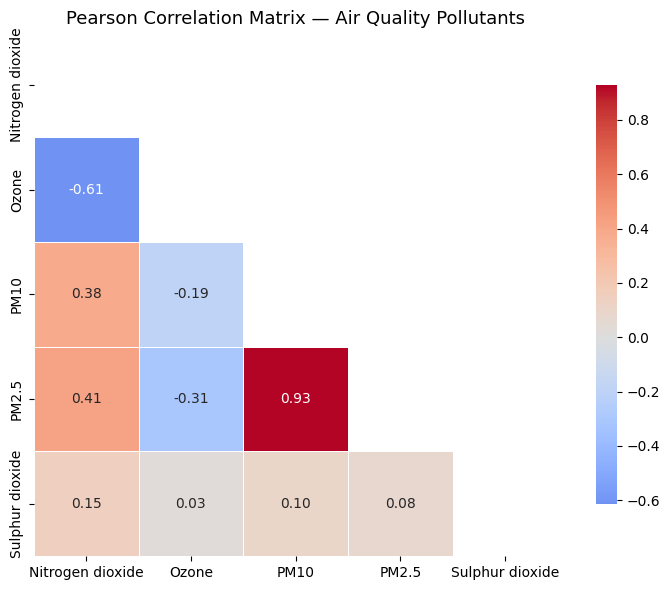

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = data.corr(method='pearson')

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title("Pearson Correlation Matrix — Air Quality Pollutants", fontsize=13)
plt.tight_layout()
plt.show()

## Step 3 — Artificial Missingness Simulation (MNAR)

**Corresponds to:** Dissertation Section 3.1, Step 2

Artificial missingness is introduced under a Missing Not at Random (MNAR) mechanism using the `MBOV_randomness` method from the `mdatagen` library. A **5% missing rate** is applied across all five pollutants, with a **randomness parameter of 0.3** meaning 70% of missingness is deterministically concentrated at the highest-concentration observations — consistent with real AURN sensor dropout behaviour during pollution peaks.

The masked values are stored in `artificial_mask` and held out exclusively for evaluation, ensuring no information leakage during imputation.


In [9]:
import numpy as np
import pandas as pd
from mdatagen.multivariate.mMNAR import mMNAR

np.random.seed(42)

data_original = data.copy()

X = data.copy()
y = np.zeros(len(data))

all_pollutants = ['Nitrogen dioxide', 'Ozone', 'PM10', 'PM2.5', 'Sulphur dioxide']

generator = mMNAR(X=X, y=y)

generate_data = generator.MBOV_randomness(
    missing_rate=5,
    columns=all_pollutants,
    randomness=0.3  # 30% randomness
)

data_missing = generate_data.copy()

artificial_mask = data_missing.isna() & (~data_original.isna())

print("Missing values per pollutant:")
print(data_missing.isna().sum())
print(f"\nTotal missing rate: {data_missing.isna().sum().sum() / data_missing.size:.5%}")

Missing values per pollutant:
Nitrogen dioxide    366
Ozone               362
PM10                360
PM2.5               365
Sulphur dioxide     362
dtype: int64

Total missing rate: 4.96241%


### 3.1 Missingness Pattern Heatmap (Figure 2 in dissertation)

White cells indicate missing values. The pattern confirms MNAR-like concentration at higher-pollution observations without systematic clustering in any single time window.

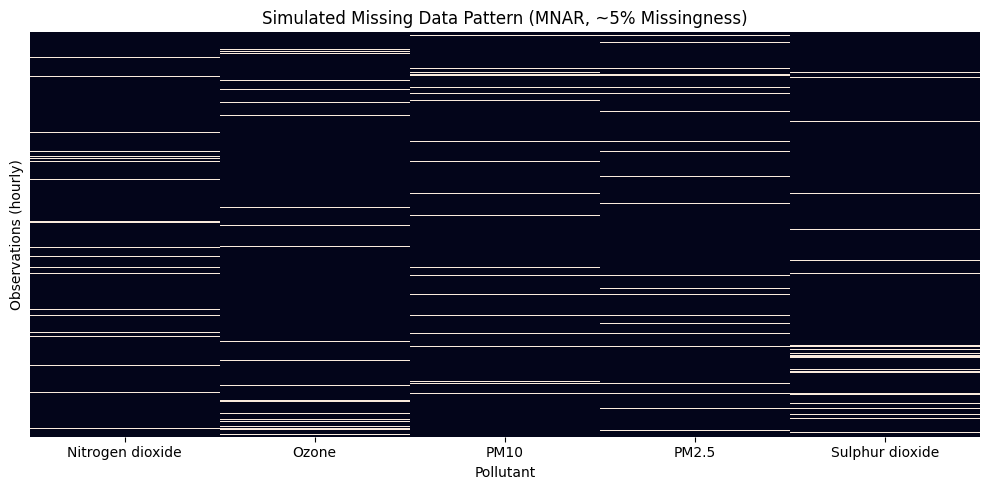

In [10]:
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.heatmap(data_missing.isna(), cbar=False, yticklabels=False,
            xticklabels=data_missing.columns)
plt.title("Simulated Missing Data Pattern (MNAR, ~5% Missingness)", fontsize=12)
plt.xlabel("Pollutant"); plt.ylabel("Observations (hourly)")
plt.tight_layout()

### 3.2 Missing Value Count

In [11]:
print("Artificial missing values:", artificial_mask.sum().sum())

Artificial missing values: 1815


## Step 4 — Imputation Methods

**Corresponds to:** Dissertation Section 3.1, Rationale for Method Selection

Six methods are applied spanning three methodological tiers as described in Table 2 of the dissertation:

| Tier | Method |
|------|--------|
| Traditional Statistical | Mean Imputation, Regression Imputation |
| Machine Learning | k-Nearest Neighbour (KNN), Random Forest (MissForest) |
| Generative AI | Autoencoder, GAIN |

Each method imputes `data_missing` and produces a complete DataFrame for evaluation.


### 4.1 Mean Imputation

Replaces all missing values with the observed column mean. Establishes the baseline performance level.

In [12]:
mean_imputer = SimpleImputer(strategy="mean")
stat_imputed = pd.DataFrame(
    mean_imputer.fit_transform(data_missing),
    columns=data.columns,
    index=data.index
)

### 4.2 k-Nearest Neighbour (KNN) Imputation

Scaler is fitted on `data_original` (ground truth) to avoid leakage. KNNImputer with k=5 identifies the five most similar complete observations and uses their values to fill each gap.

In [13]:
scaler_knn = MinMaxScaler()
scaler_knn.fit(data_original)  # fit on complete ground truth

knn_imputer = KNNImputer(n_neighbors=5)
knn_scaled = knn_imputer.fit_transform(
    scaler_knn.transform(data_missing.fillna(data_missing.mean()))
)

knn_imputed = pd.DataFrame(
    scaler_knn.inverse_transform(knn_scaled),
    columns=data_missing.columns,
    index=data_missing.index
)

### 4.3 Linear Regression Imputation

For each pollutant with missing values, a separate linear regression model is trained on observed rows using all other pollutants as predictors. Directly models inter-variable dependencies.

In [14]:
def regression_impute(df):
    df_filled = df.copy()

    for col in df.columns:
        missing = df[col].isna()

        if missing.sum() > 0:
            X_train = df.loc[~missing].drop(columns=col)
            y_train = df.loc[~missing, col]
            X_test = df.loc[missing].drop(columns=col)

            model = LinearRegression()
            model.fit(X_train.fillna(X_train.mean()), y_train)

            df_filled.loc[missing, col] = model.predict(
                X_test.fillna(X_train.mean())
            )

    return df_filled

reg_imputed = regression_impute(data_missing)

### 4.4 Random Forest Imputation (MissForest)

Uses `IterativeImputer` with `RandomForestRegressor` (100 trees, random_state=42). Captures non-linear inter-pollutant relationships through an ensemble of decision trees fitted iteratively across all variables.

In [15]:
rf_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100, random_state=42),
    max_iter=10,
    random_state=42
)

rf_imputed = pd.DataFrame(
    rf_imputer.fit_transform(data_missing),
    columns=data.columns,
    index=data.index
)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


### 4.5 Autoencoder Imputation

A symmetric encoder-decoder neural network (64→32→16→32→64) learns a compressed latent representation of the complete pollutant space. Scaler is fitted on `data_original`. Row-level sample weights downweight heavily incomplete rows during training. Early stopping (patience=20) prevents overfitting.

In [16]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_original)
data_missing_scaled = scaler.transform(data_missing.fillna(data_original.mean()))
data_scaled_zero_filled = np.nan_to_num(data_missing_scaled, nan=0.0).astype(np.float32)

# Row-level mask: fraction of observed features per row, used as sample weight
row_mask = (~data_missing.isna()).astype(np.float32).mean(axis=1).values

input_dim = data_scaled_zero_filled.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
encoded = Dense(16, activation='relu')(encoded)
decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(decoded)
output_layer = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='loss', patience=20, restore_best_weights=True)

history = autoencoder.fit(
    data_scaled_zero_filled,
    data_scaled_zero_filled,
    sample_weight=row_mask,
    epochs=300,
    batch_size=32,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

ae_output_scaled = autoencoder.predict(data_scaled_zero_filled)
ae_output = scaler.inverse_transform(ae_output_scaled)

imputed_array = data_missing.values.copy()
missing_mask = data_missing.isna().values
imputed_array[missing_mask] = ae_output[missing_mask]

ae_imputed = pd.DataFrame(imputed_array, columns=data.columns, index=data.index)

Epoch 1/300
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0044
Epoch 2/300
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.1615e-04
Epoch 3/300
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.2880e-05
Epoch 4/300
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.4966e-05
Epoch 5/300
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.8022e-05
Epoch 6/300
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.4624e-05
Epoch 7/300
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.5536e-06
Epoch 8/300
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.8121e-06
Epoch 9/300
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3.8459e-06
Epoch 10/300
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.7406e-06
Epoch 11/300
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.6301e-06
Epoch 12/300
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6646e-06
Epoch 13/300
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5384e-06
Epoch 14/300
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.

### 4.5a Autoencoder Training Loss

Visualises convergence of the autoencoder during training.

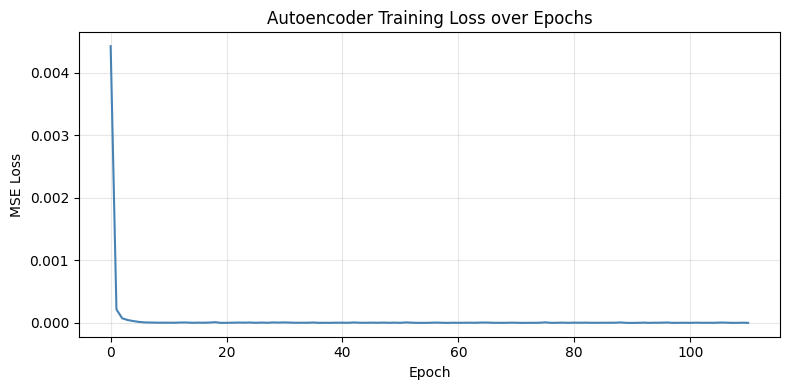

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], color='steelblue', linewidth=1.5)
plt.title("Autoencoder Training Loss over Epochs", fontsize=12)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.6 GAIN (Generative Adversarial Imputation Network)

A generator-discriminator adversarial framework where the generator produces candidate imputations that must deceive a discriminator. Random seeds are fixed (np.random.seed(42), tf.random.set_seed(42)) for reproducibility. Hint rate=0.8, alpha=50, epochs=8000, batch_size=32.

In [18]:
import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '42'

np.random.seed(42)
tf.random.set_seed(42)

import numpy as np
import pandas as pd
from tensorflow.keras.layers import Dense, LeakyReLU
from sklearn.preprocessing import MinMaxScaler

scaler_gain = MinMaxScaler()
scaler_gain.fit(data_original)
data_temp = data_missing.fillna(0)
data_scaled = scaler_gain.transform(data_temp).astype(np.float32)

mask_gain = (~np.isnan(data_missing.values)).astype(np.float32)

dim = data_scaled.shape[1]
batch_size = 32
epochs = 8000
hint_rate = 0.8
alpha = 50

def build_generator():
    model = tf.keras.Sequential([
        Dense(256, input_shape=(dim*2,),
              kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42)),
        LeakyReLU(alpha=0.2),
        Dense(256,
              kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42)),
        LeakyReLU(alpha=0.2),
        Dense(128,
              kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42)),
        LeakyReLU(alpha=0.2),
        Dense(dim, activation='sigmoid',
              kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42))
    ])
    return model

def build_discriminator():
    model = tf.keras.Sequential([
        Dense(256, input_shape=(dim*2,),
              kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42)),
        LeakyReLU(alpha=0.2),
        Dense(256,
              kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42)),
        LeakyReLU(alpha=0.2),
        Dense(128,
              kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42)),
        LeakyReLU(alpha=0.2),
        Dense(dim, activation='sigmoid',
              kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42))
    ])
    return model

generator = build_generator()
discriminator = build_discriminator()

g_optimizer = tf.keras.optimizers.Adam(2e-4)
d_optimizer = tf.keras.optimizers.Adam(2e-4)

bce = tf.keras.losses.BinaryCrossentropy()
mse = tf.keras.losses.MeanSquaredError()
rng = np.random.default_rng(42)

for epoch in range(epochs):

    idx = rng.integers(0, data_scaled.shape[0], batch_size)

    X_batch = data_scaled[idx]
    M_batch = mask_gain[idx]

    Z_batch = rng.uniform(0, 0.01, size=X_batch.shape).astype(np.float32)

    X_tilde = M_batch * X_batch + (1 - M_batch) * Z_batch

    H = rng.binomial(1, hint_rate, size=M_batch.shape).astype(np.float32)
    H = M_batch * H

    with tf.GradientTape() as tape:
        G_input = tf.concat([X_tilde, M_batch], axis=1)
        G_sample = generator(G_input)
        X_hat = M_batch * X_batch + (1 - M_batch) * G_sample
        D_input = tf.concat([X_hat, H], axis=1)
        D_prob = discriminator(D_input)
        D_loss = bce(M_batch, D_prob)

    D_grad = tape.gradient(D_loss, discriminator.trainable_variables)
    d_optimizer.apply_gradients(zip(D_grad, discriminator.trainable_variables))

    with tf.GradientTape() as tape:
        G_input = tf.concat([X_tilde, M_batch], axis=1)
        G_sample = generator(G_input)
        X_hat = M_batch * X_batch + (1 - M_batch) * G_sample
        D_input = tf.concat([X_hat, H], axis=1)
        D_prob = discriminator(D_input)
        G_loss_adv = bce(tf.ones_like(D_prob), D_prob)
        G_loss_mse = mse(M_batch * X_batch, M_batch * G_sample)
        G_loss = G_loss_adv + alpha * G_loss_mse

    G_grad = tape.gradient(G_loss, generator.trainable_variables)
    g_optimizer.apply_gradients(zip(G_grad, generator.trainable_variables))

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: D_loss={D_loss.numpy():.4f}, G_loss={G_loss.numpy():.4f}")

Z_full = rng.uniform(0, 0.01, size=data_scaled.shape).astype(np.float32)
X_tilde_full = mask_gain * data_scaled + (1 - mask_gain) * Z_full

G_input = tf.concat([X_tilde_full, mask_gain], axis=1)
G_sample_full = generator(G_input).numpy()

gain_output = mask_gain * data_scaled + (1 - mask_gain) * G_sample_full

gain_imputed = pd.DataFrame(
    scaler_gain.inverse_transform(gain_output),
    columns=data.columns,
    index=data.index
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 0: D_loss=0.7107, G_loss=6.3157
Epoch 500: D_loss=0.1271, G_loss=0.1045
Epoch 1000: D_loss=0.1529, G_loss=0.1011
Epoch 1500: D_loss=0.0879, G_loss=0.0408
Epoch 2000: D_loss=0.1189, G_loss=0.0715
Epoch 2500: D_loss=0.0972, G_loss=0.0573
Epoch 3000: D_loss=0.1153, G_loss=0.0803
Epoch 3500: D_loss=0.0998, G_loss=0.3558
Epoch 4000: D_loss=0.0980, G_loss=0.0738
Epoch 4500: D_loss=0.1320, G_loss=0.1029
Epoch 5000: D_loss=0.1117, G_loss=0.0458
Epoch 5500: D_loss=0.1049, G_loss=0.1102
Epoch 6000: D_loss=0.1488, G_loss=0.0510
Epoch 6500: D_loss=0.0719, G_loss=0.0649
Epoch 7000: D_loss=0.1008, G_loss=0.0514
Epoch 7500: D_loss=0.1255, G_loss=0.0437


## Step 5 — Reconstruction Accuracy Evaluation

**Corresponds to:** Dissertation Section 3.1, Step 3 (Evaluation Metrics) and Section 4 (Results)

Three complementary metrics are computed for each method–pollutant combination against the held-out ground-truth values:

- **RMSE** — penalises large errors more heavily; sensitive to extreme imputation failures
- **MAE** — treats all errors proportionally; direct measure in original μg/m³ units
- **R²** — proportion of variance explained; negative values indicate worse than mean imputation


### 5.1 Evaluation Function

In [19]:
def evaluate(true, imputed, artificial_mask):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    import numpy as np

    results_df = {}
    for col in true.select_dtypes(include=np.number).columns:
        mask_col = artificial_mask[col].astype(bool) & ~true[col].isna()
        y_true_col = true[col][mask_col]
        y_pred_col = imputed[col][mask_col]

        results_df[col] = {
            "RMSE": np.sqrt(mean_squared_error(y_true_col, y_pred_col)),
            "MAE": mean_absolute_error(y_true_col, y_pred_col),
            "R2": r2_score(y_true_col, y_pred_col)
        }
    return results_df

### 5.2 Compute Results for All Methods

In [20]:
results_dict = {
    "Mean": evaluate(data, stat_imputed, artificial_mask),
    "KNN": evaluate(data, knn_imputed, artificial_mask),
    "Regression": evaluate(data, reg_imputed, artificial_mask),
    "Random Forest": evaluate(data, rf_imputed, artificial_mask),
    "Autoencoder": evaluate(data, ae_imputed, artificial_mask),
    "GAIN": evaluate(data, gain_imputed, artificial_mask)
}

In [21]:
rows = []

for method, pollutants in results_dict.items():
    for pollutant, metrics in pollutants.items():
        rows.append({
            "Method": method,
            "Pollutant": pollutant,
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"]
        })

results_df = pd.DataFrame(rows)
print(results_df)

           Method         Pollutant       RMSE        MAE        R2
0            Mean  Nitrogen dioxide  16.150761  15.142585 -1.394771
1            Mean             Ozone  38.819679  35.728510 -1.921507
2            Mean              PM10   9.659082   8.942876 -1.494688
3            Mean             PM2.5   6.187953   5.591437 -0.882784
4            Mean   Sulphur dioxide   0.717371   0.671538 -1.706093
5             KNN  Nitrogen dioxide  16.150761  15.142585 -1.394771
6             KNN             Ozone  38.819679  35.728510 -1.921507
7             KNN              PM10   9.659082   8.942876 -1.494688
8             KNN             PM2.5   6.187953   5.591437 -0.882784
9             KNN   Sulphur dioxide   0.717371   0.671538 -1.706093
10     Regression  Nitrogen dioxide  12.259280  11.084010 -0.379774
11     Regression             Ozone  20.350610  17.151700  0.197107
12     Regression              PM10   7.952493   6.725476 -0.691030
13     Regression             PM2.5   4.670136  

### 5.3 Per-Variable Metrics Function (unified RMSE / MAE / R²)

In [22]:
def per_variable_metrics(true, imputed, artificial_mask):
    results = {}
    for i, col in enumerate(true.columns):
        combined_mask_col = artificial_mask.values[:, i] & ~np.isnan(true[col].values)
        true_vals = true[col].values[combined_mask_col]
        pred_vals = imputed[col].values[combined_mask_col]
        valid = ~np.isnan(pred_vals)
        true_vals = true_vals[valid]
        pred_vals = pred_vals[valid]
        if len(true_vals) > 0:
            results[col] = {
                'RMSE': np.sqrt(mean_squared_error(true_vals, pred_vals)),
                'MAE':  mean_absolute_error(true_vals, pred_vals),
                'R2':   r2_score(true_vals, pred_vals)
            }
        else:
            results[col] = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
    return results

method_results = {
    'Mean':          per_variable_metrics(data, stat_imputed, artificial_mask),
    'KNN':           per_variable_metrics(data, knn_imputed, artificial_mask),
    'Regression':    per_variable_metrics(data, reg_imputed, artificial_mask),
    'Random Forest': per_variable_metrics(data, rf_imputed, artificial_mask),
    'Autoencoder':   per_variable_metrics(data, ae_imputed, artificial_mask),
    'GAIN':          per_variable_metrics(data, gain_imputed, artificial_mask),
}

rmse_comparison_table = pd.DataFrame(
    {m: {col: v['RMSE'] for col, v in res.items()} for m, res in method_results.items()}
)
mae_comparison_table = pd.DataFrame(
    {m: {col: v['MAE']  for col, v in res.items()} for m, res in method_results.items()}
)
r2_comparison_table = pd.DataFrame(
    {m: {col: v['R2']   for col, v in res.items()} for m, res in method_results.items()}
)

print(rmse_comparison_table)

                       Mean        KNN  Regression  Random Forest  \
Nitrogen dioxide  16.150761  16.150761   12.259280      10.651598   
Ozone             38.819679  38.819679   20.350610      20.018003   
PM10               9.659082   9.659082    7.952493       6.712308   
PM2.5              6.187953   6.187953    4.670136       3.882475   
Sulphur dioxide    0.717371   0.717371    0.657688       0.662059   

                  Autoencoder       GAIN  
Nitrogen dioxide    15.656479  18.394295  
Ozone               37.693665  18.049053  
PM10                 9.375257   5.404274  
PM2.5                6.052355   4.356558  
Sulphur dioxide      0.685930   0.454474  


### 5.4 Individual Metric Functions (RMSE / MAE / R²)

In [23]:
def rmse_per_variable(true, imputed, artificial_mask):

    results = {}

    for i, col in enumerate(true.columns):

        combined_mask_col = artificial_mask.values[:, i] & ~np.isnan(true[col].values)

        true_vals = true[col].values[combined_mask_col]
        pred_vals = imputed[col].values[combined_mask_col]

        if len(true_vals) > 0:
            results[col] = np.sqrt(mean_squared_error(true_vals, pred_vals))
        else:
            results[col] = np.nan

    return pd.Series(results)

In [24]:
def mae_per_variable(true, imputed, artificial_mask):

    results = {}

    for i, col in enumerate(true.columns):

        combined_mask_col = artificial_mask.values[:, i] & ~np.isnan(true[col].values)

        true_vals = true[col].values[combined_mask_col]
        pred_vals = imputed[col].values[combined_mask_col]

        if len(true_vals) > 0:
            results[col] = mean_absolute_error(true_vals, pred_vals)
        else:
            results[col] = np.nan

    return pd.Series(results)

In [25]:
def r2_per_variable(true, imputed, artificial_mask):

    results = {}

    for i, col in enumerate(true.columns):

        combined_mask_col = artificial_mask.values[:, i] & ~np.isnan(true[col].values)

        true_vals = true[col].values[combined_mask_col]
        pred_vals = imputed[col].values[combined_mask_col]

        valid = ~np.isnan(pred_vals)

        true_vals = true_vals[valid]
        pred_vals = pred_vals[valid]

        if len(true_vals) > 0:
            results[col] = r2_score(true_vals, pred_vals)
        else:
            results[col] = np.nan

    return pd.Series(results)

### 5.5 Build Comparison Tables

In [26]:
rmse_comparison_table = pd.DataFrame({

    "Mean": rmse_per_variable(data, stat_imputed, artificial_mask),

    "KNN": rmse_per_variable(data, knn_imputed, artificial_mask),

    "Regression": rmse_per_variable(data, reg_imputed, artificial_mask),

    "Random Forest": rmse_per_variable(data, rf_imputed, artificial_mask),

    "Autoencoder": rmse_per_variable(data, ae_imputed, artificial_mask),

    "GAIN": rmse_per_variable(data, gain_imputed, artificial_mask)

})

rmse_comparison_table

,Mean,KNN,Regression,Random Forest,Autoencoder,GAIN
Nitrogen dioxide,16.150761,16.150761,12.259280,10.651598,15.656479,18.394295
Ozone,38.819679,38.819679,20.350610,20.018003,37.693665,18.049053
PM10,9.659082,9.659082,7.952493,6.712308,9.375257,5.404274
PM2.5,6.187953,6.187953,4.670136,3.882475,6.052355,4.356558
Sulphur dioxide,0.717371,0.717371,0.657688,0.662059,0.685930,0.454474


In [27]:
mae_comparison_table = pd.DataFrame({

    "Mean": mae_per_variable(data, stat_imputed, artificial_mask),

    "KNN": mae_per_variable(data, knn_imputed, artificial_mask),

    "Regression": mae_per_variable(data, reg_imputed, artificial_mask),

    "Random Forest": mae_per_variable(data, rf_imputed, artificial_mask),

    "Autoencoder": mae_per_variable(data, ae_imputed, artificial_mask),

    "GAIN": mae_per_variable(data, gain_imputed, artificial_mask)

})

mae_comparison_table

,Mean,KNN,Regression,Random Forest,Autoencoder,GAIN
Nitrogen dioxide,15.142585,15.142585,11.084010,9.526878,14.662501,17.228905
Ozone,35.728510,35.728510,17.151700,17.124588,34.756933,15.782301
PM10,8.942876,8.942876,6.725476,5.332496,8.652085,3.480835
PM2.5,5.591437,5.591437,3.878958,3.007110,5.432221,3.020853
Sulphur dioxide,0.671538,0.671538,0.612325,0.600833,0.641582,0.259898


In [28]:
r2_comparison_table = pd.DataFrame({

    "Mean": r2_per_variable(data, stat_imputed, artificial_mask),

    "KNN": r2_per_variable(data, knn_imputed, artificial_mask),

    "Regression": r2_per_variable(data, reg_imputed, artificial_mask),

    "Random Forest": r2_per_variable(data, rf_imputed, artificial_mask),

    "Autoencoder": r2_per_variable(data, ae_imputed, artificial_mask),

    "GAIN": r2_per_variable(data, gain_imputed, artificial_mask)

})

r2_comparison_table

,Mean,KNN,Regression,Random Forest,Autoencoder,GAIN
Nitrogen dioxide,-1.394771,-1.394771,-0.379774,-0.041616,-1.250434,-2.106307
Ozone,-1.921507,-1.921507,0.197107,0.223137,-1.754481,0.368444
PM10,-1.494688,-1.494688,-0.691030,-0.204726,-1.350233,0.219057
PM2.5,-0.882784,-0.882784,-0.072422,0.258820,-0.801173,0.066759
Sulphur dioxide,-1.706093,-1.706093,-1.274552,-1.304886,-1.474086,-0.086108


## Step 6 — Results Visualisation

**Corresponds to:** Dissertation Sections 4.2–4.5 (Figures 4–11)

All visualisations used in the dissertation are reproduced below in the order they appear in the report.


### 6.1 RMSE Heatmap (Figure 4) — Darker = higher error

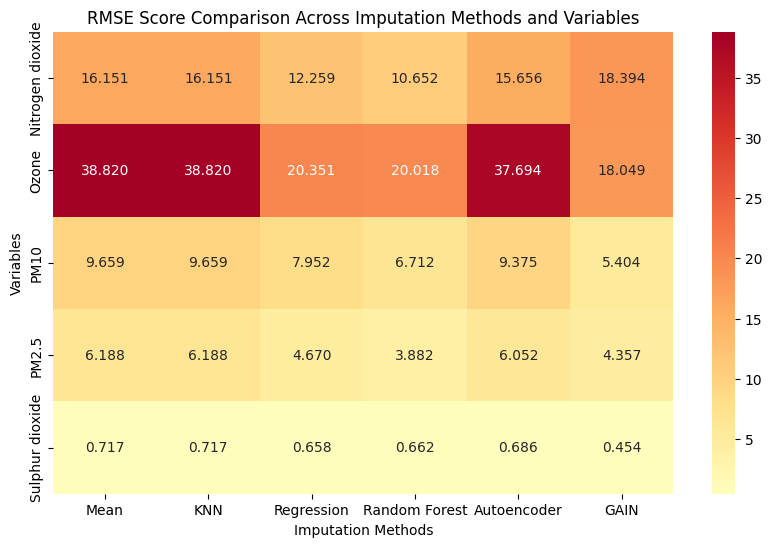

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    rmse_comparison_table,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn_r",
    center=0
)

plt.title("RMSE Score Comparison Across Imputation Methods and Variables")
plt.xlabel("Imputation Methods")
plt.ylabel("Variables")

plt.show()

### 6.2 MAE Heatmap (Figure 5)

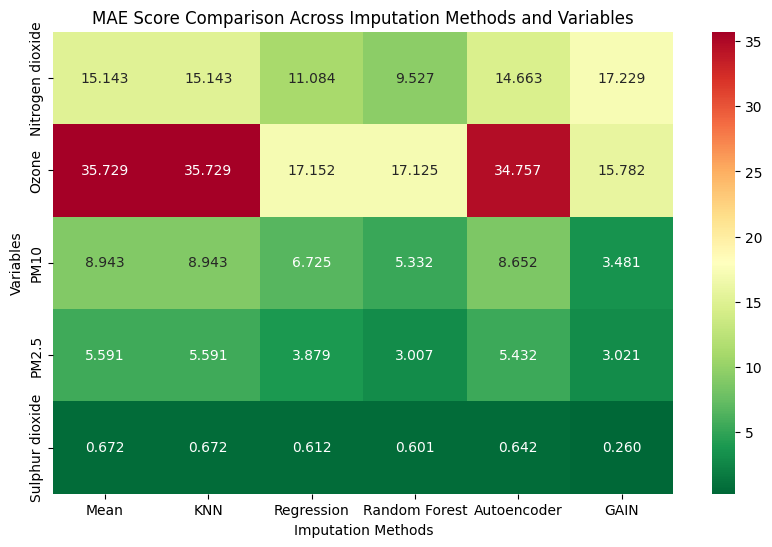

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    mae_comparison_table,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn_r",
)

plt.title("MAE Score Comparison Across Imputation Methods and Variables")
plt.xlabel("Imputation Methods")
plt.ylabel("Variables")

plt.show()

### 6.3 R² Heatmap (Figure 6) — Values near 1.0 = excellent; negative = worse than mean

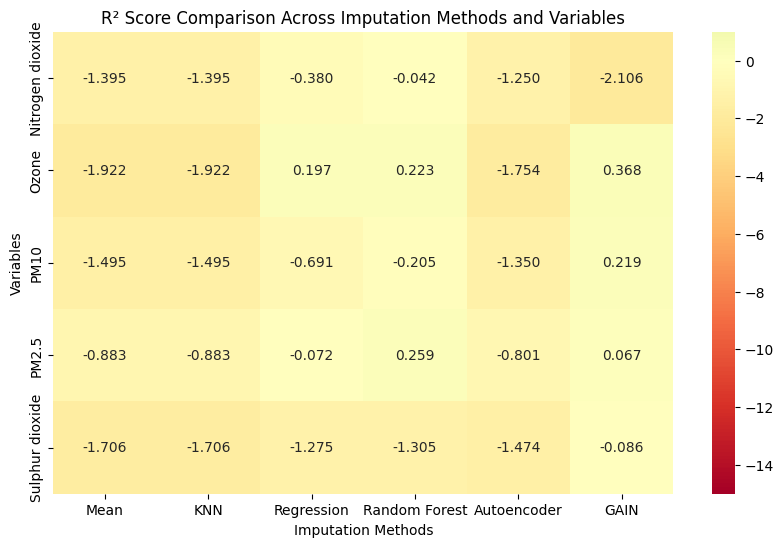

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(r2_comparison_table, annot=True, fmt=".3f",
            cmap="RdYlGn", center=0,
            vmin=-15, vmax=1)

plt.title("R² Score Comparison Across Imputation Methods and Variables")
plt.xlabel("Imputation Methods")
plt.ylabel("Variables")

plt.show()

### 6.4 Scatter Plots — True vs Imputed for NO₂ (Figure 7)

The red dashed line represents perfect imputation. Tighter clustering around this line indicates better reconstruction.

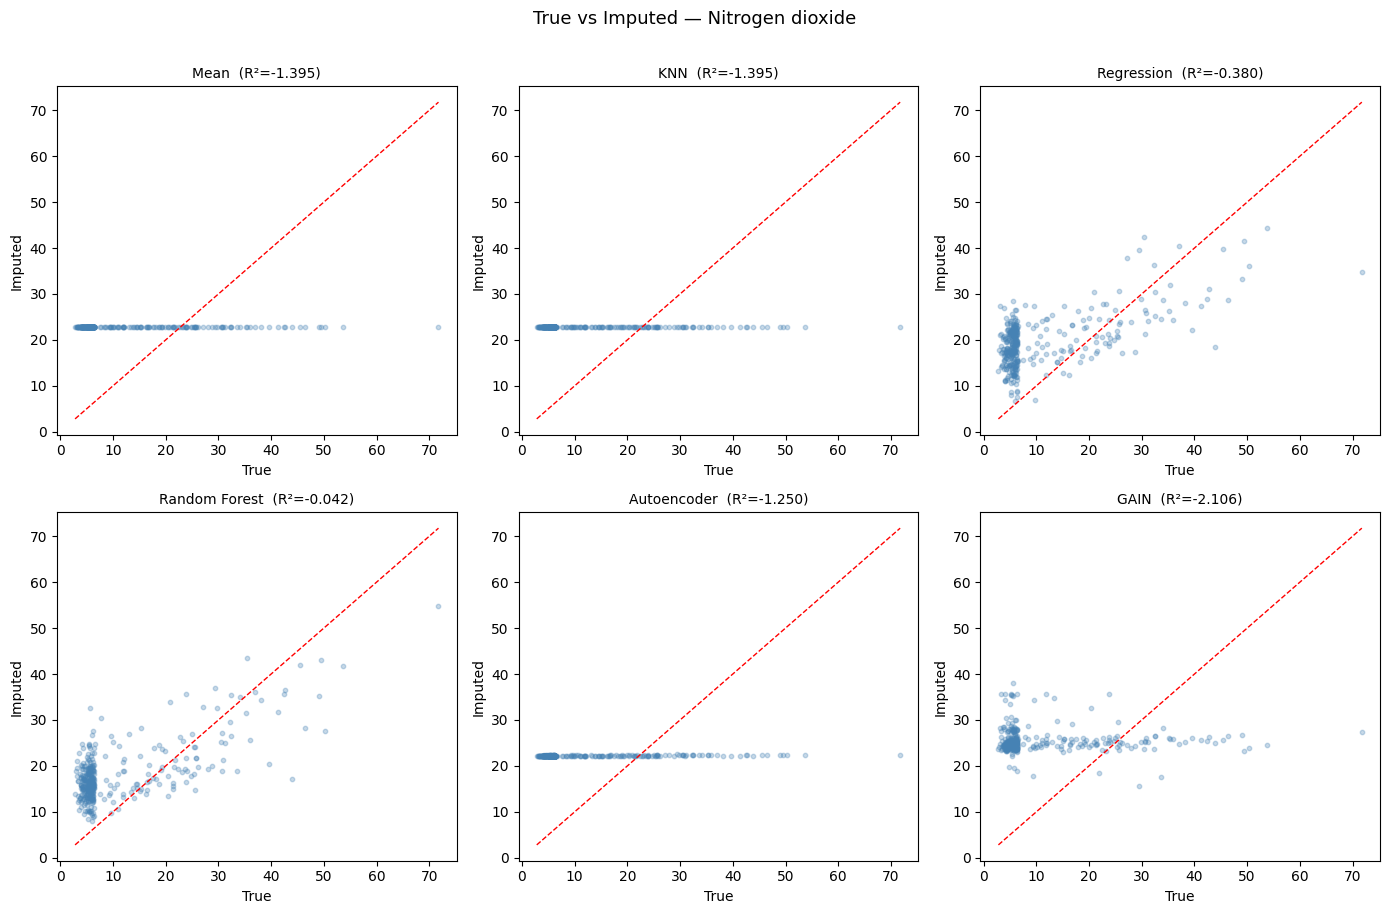

In [32]:
methods = {
    "Mean": stat_imputed,
    "KNN": knn_imputed,
    "Regression": reg_imputed,
    "Random Forest": rf_imputed,
    "Autoencoder": ae_imputed,
    "GAIN": gain_imputed
}

col = "Nitrogen dioxide"
valid = artificial_mask[col].astype(bool) & ~data[col].isna()
y_true = data[col][valid]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for ax, (name, imp) in zip(axes, methods.items()):
    y_pred = imp[col][valid]
    ax.scatter(y_true, y_pred, alpha=0.3, s=10, color='steelblue')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    r2 = r2_score(y_true, y_pred)
    ax.set_title(f"{name}  (R²={r2:.3f})", fontsize=10)
    ax.set_xlabel("True"); ax.set_ylabel("Imputed")

plt.suptitle(f"True vs Imputed — {col}", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 6.5 Error Distribution — NO₂ (Figure 8)

Left-shifted distributions indicate systematic underestimation, consistent with MNAR conditions where higher values are preferentially missing.

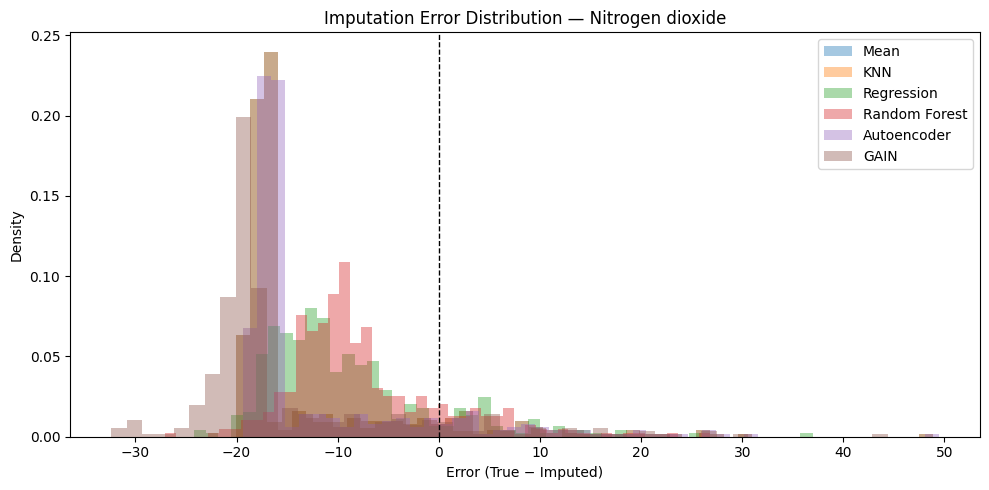

In [33]:
methods = {
    "Mean": stat_imputed,
    "KNN": knn_imputed,
    "Regression": reg_imputed,
    "Random Forest": rf_imputed,
    "Autoencoder": ae_imputed,
    "GAIN": gain_imputed
}

col = "Nitrogen dioxide"
valid = artificial_mask[col].astype(bool) & ~data[col].isna()
y_true = data[col][valid]

plt.figure(figsize=(10, 5))
for name, imp in methods.items():
    errors = y_true.values - imp[col][valid].values
    plt.hist(errors, bins=50, alpha=0.4, label=name, density=True)

plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.title(f"Imputation Error Distribution — {col}", fontsize=12)
plt.xlabel("Error (True − Imputed)"); plt.ylabel("Density")
plt.legend()
plt.tight_layout()

### 6.6 Boxplots — Variance Preservation for NO₂ (Figure 9)

Closer alignment with the original distribution indicates better preservation of the pollutant's statistical spread.

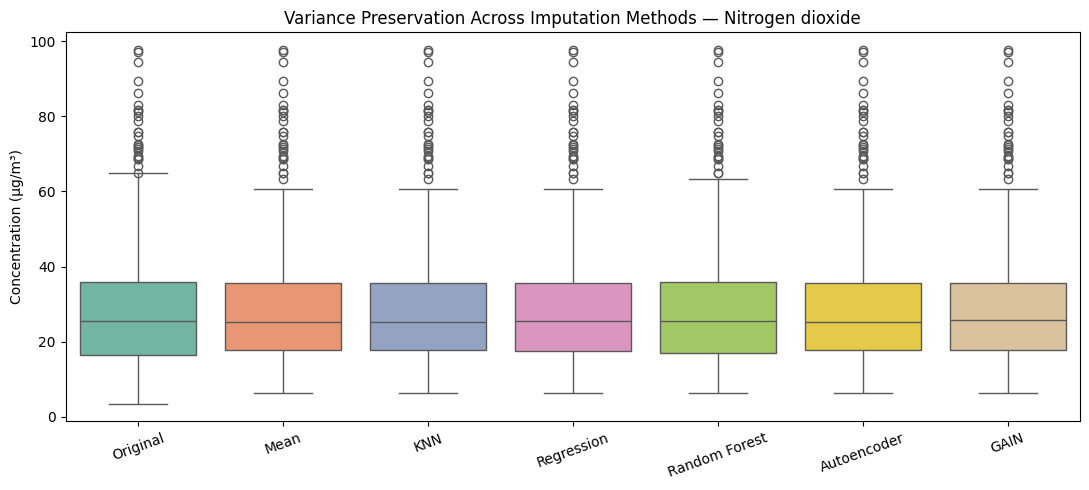

In [34]:
import seaborn as sns

col = "Nitrogen dioxide"
box_data = pd.DataFrame({
    "Original":      data[col].dropna().values[:1000],
    "Mean":          stat_imputed[col].values[:1000],
    "KNN":           knn_imputed[col].values[:1000],
    "Regression":    reg_imputed[col].values[:1000],
    "Random Forest": rf_imputed[col].values[:1000],
    "Autoencoder":   ae_imputed[col].values[:1000],
    "GAIN":          gain_imputed[col].values[:1000],
})

plt.figure(figsize=(11, 5))
sns.boxplot(data=box_data, palette="Set2")
plt.title(f"Variance Preservation Across Imputation Methods — {col}", fontsize=12)
plt.ylabel("Concentration (μg/m³)")
plt.xticks(rotation=20)
plt.tight_layout()

### 6.7 Radar Chart — Overall Normalised Performance (Figure 10)

Outermost positions on each axis indicate best performance. Confirms GAIN and Random Forest jointly dominate across all three metrics.

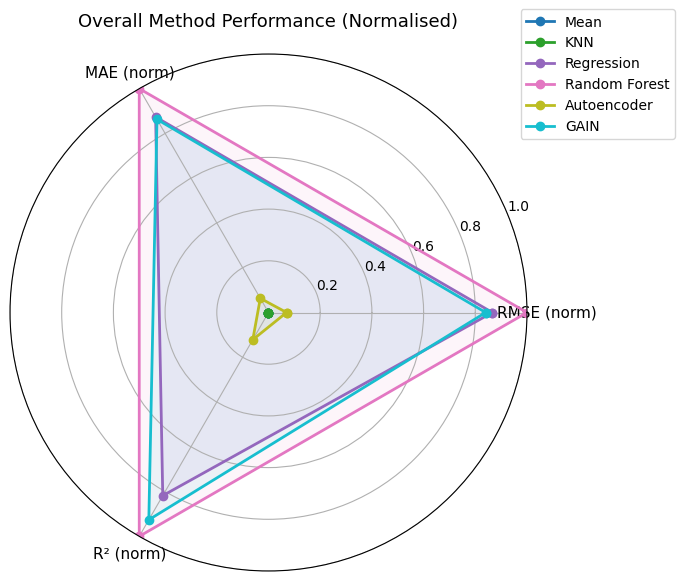

In [35]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Normalise RMSE so lower=better becomes higher=better, scale 0-1
def normalise_score(series, higher_is_better=False):
    if higher_is_better:
        return (series - series.min()) / (series.max() - series.min() + 1e-9)
    else:
        return 1 - (series - series.min()) / (series.max() - series.min() + 1e-9)

method_names = list(methods.keys())
pollutants = list(data.columns)

rmse_mean = rmse_comparison_table.mean()
mae_mean  = mae_comparison_table.mean()
r2_mean   = r2_comparison_table.mean()

scores = pd.DataFrame({
    'RMSE (norm)': normalise_score(rmse_mean, higher_is_better=False),
    'MAE (norm)':  normalise_score(mae_mean,  higher_is_better=False),
    'R² (norm)':   normalise_score(r2_mean,   higher_is_better=True),
})

categories = list(scores.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors = plt.cm.tab10(np.linspace(0, 1, len(method_names)))

for i, method in enumerate(method_names):
    vals = scores.loc[method].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=method, color=colors[i])
    ax.fill(angles, vals, alpha=0.07, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Overall Method Performance (Normalised)", fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

### 6.8 Density Plots — Distribution Preservation Across All Pollutants (Figure 11)

Blue = original distribution, Orange = imputed. Closer overlap indicates better distributional preservation.

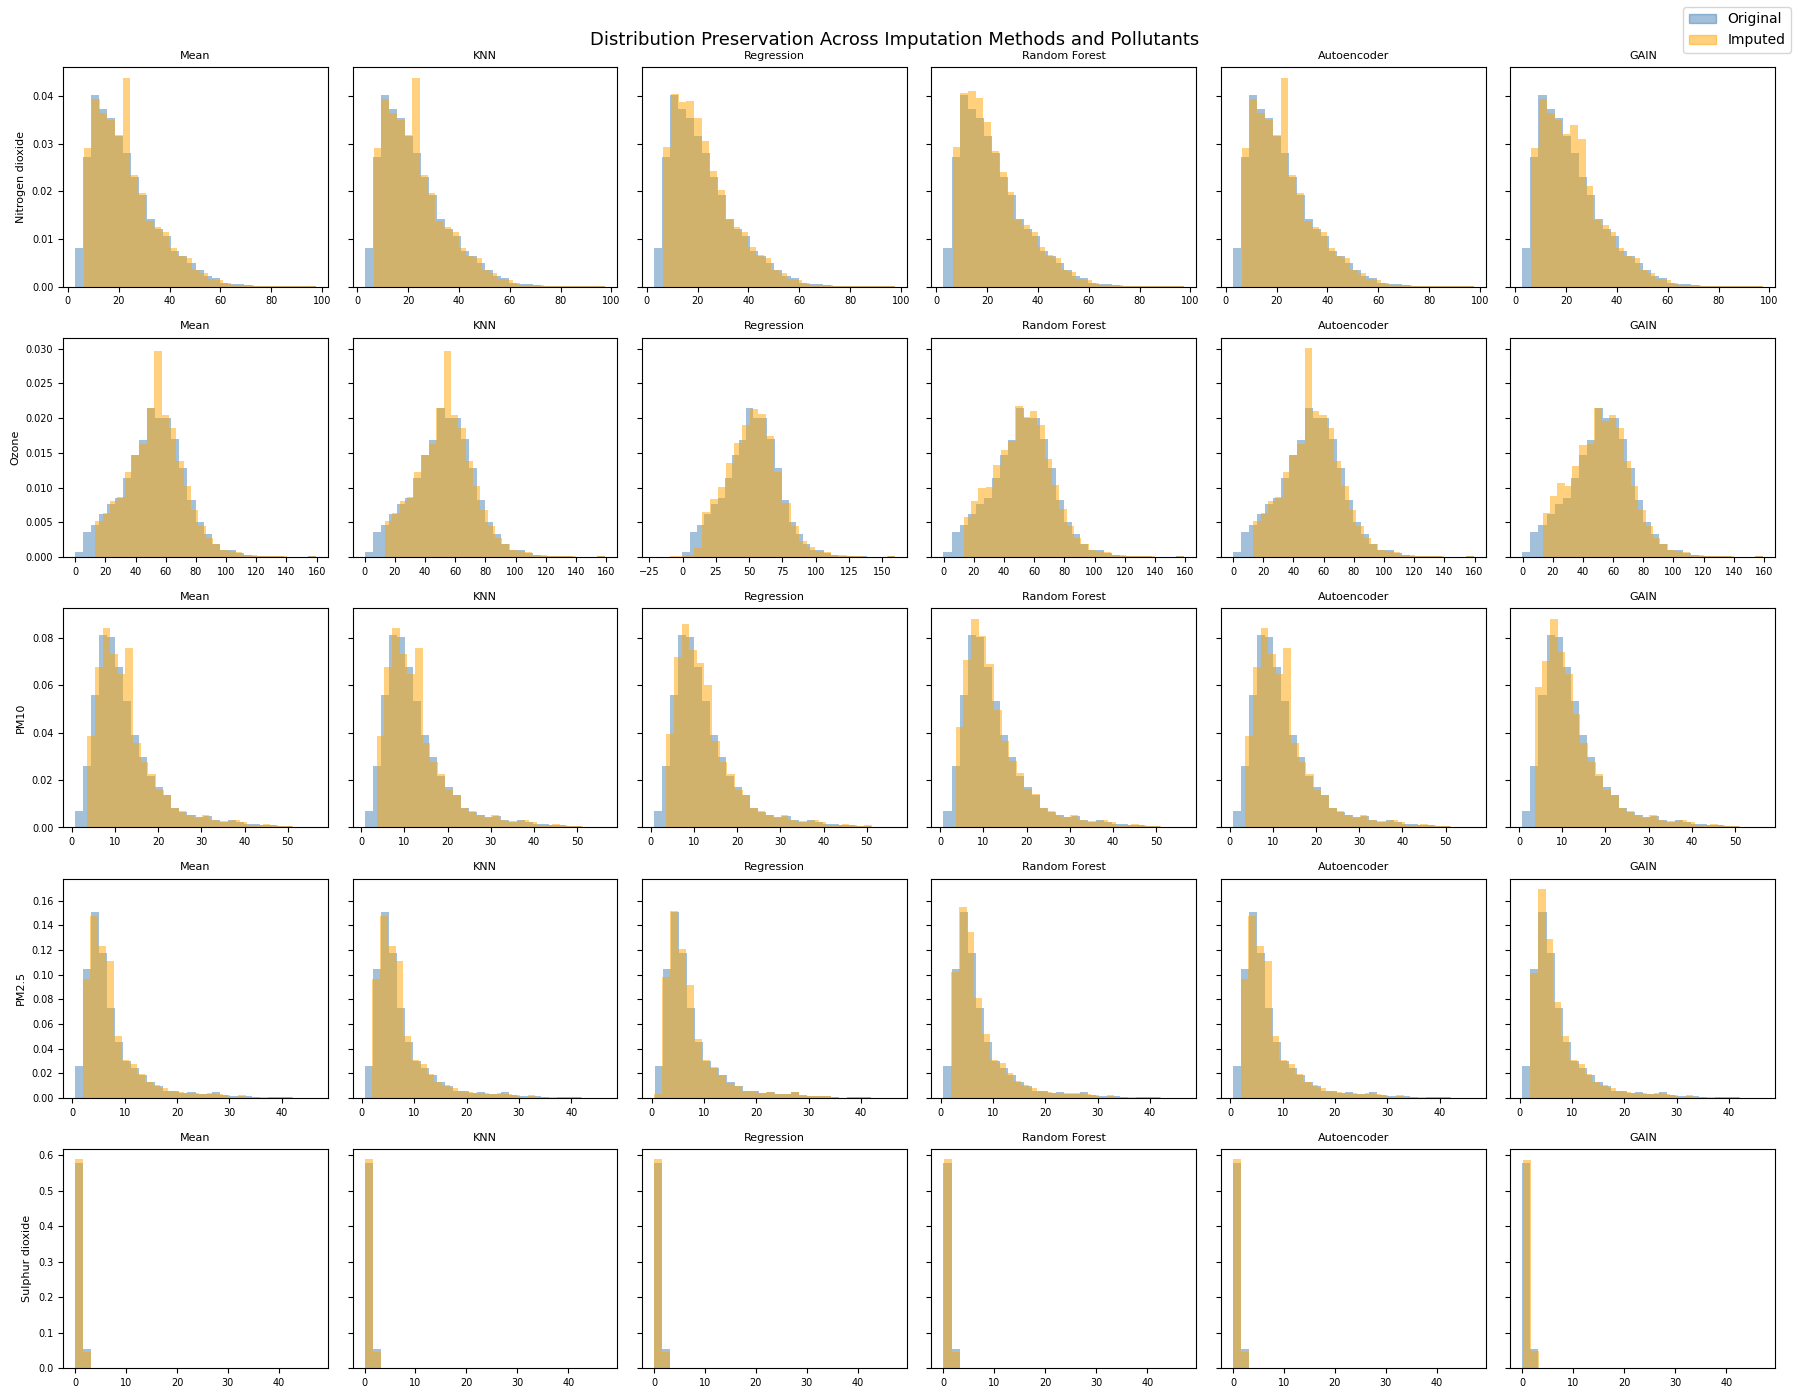

In [36]:
fig, axes = plt.subplots(len(data.columns), len(methods), figsize=(18, 14), sharey='row')

for row_idx, col in enumerate(data.columns):
    for col_idx, (name, imp) in enumerate(methods.items()):
        ax = axes[row_idx][col_idx]
        ax.hist(data[col].dropna(), bins=30, alpha=0.5, label='Original', color='steelblue', density=True)
        ax.hist(imp[col].dropna(), bins=30, alpha=0.5, label='Imputed', color='orange', density=True)
        ax.set_title(f"{name}", fontsize=8)
        if col_idx == 0:
            ax.set_ylabel(col, fontsize=8)
        ax.tick_params(labelsize=7)

handles = [plt.Rectangle((0,0),1,1, color='steelblue', alpha=0.5),
           plt.Rectangle((0,0),1,1, color='orange', alpha=0.5)]
fig.legend(handles, ['Original', 'Imputed'], loc='upper right', fontsize=10)
plt.suptitle("Distribution Preservation Across Imputation Methods and Pollutants", fontsize=13)
plt.tight_layout()
plt.show()

## Step 7 — Supplementary Visualisations

Additional visualisations not used as primary dissertation figures but included for completeness and transparency.


### 7.1 Bar Charts — RMSE, MAE, R² by Pollutant

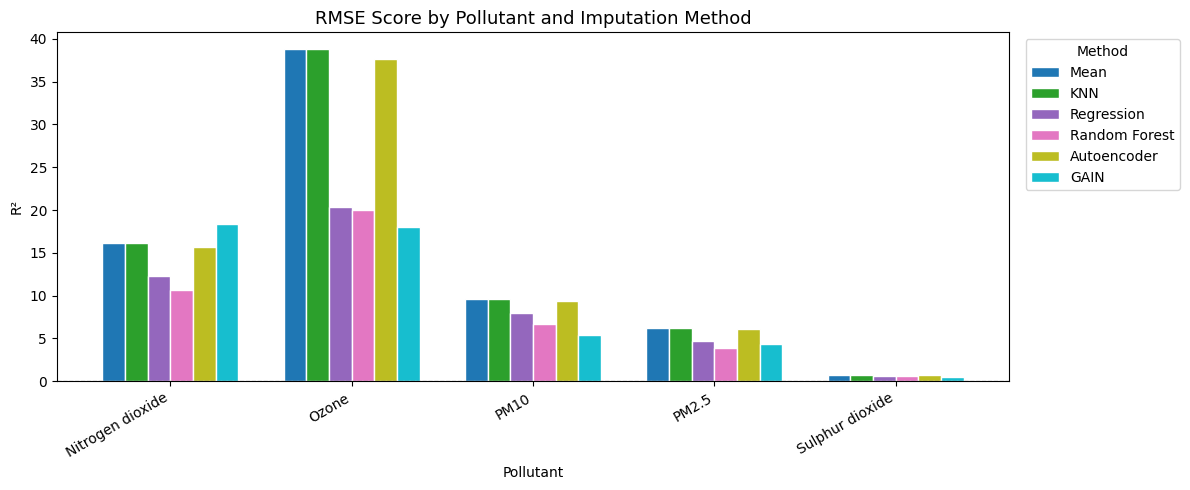

In [37]:
rmse_plot = rmse_comparison_table.copy()

ax = rmse_plot.plot(kind='bar', figsize=(12, 5), width=0.75,
                  colormap='tab10', edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("RMSE Score by Pollutant and Imputation Method", fontsize=13)
ax.set_xlabel("Pollutant"); ax.set_ylabel("R²")
ax.set_xticklabels(rmse_plot.index, rotation=30, ha='right')
ax.legend(title='Method', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

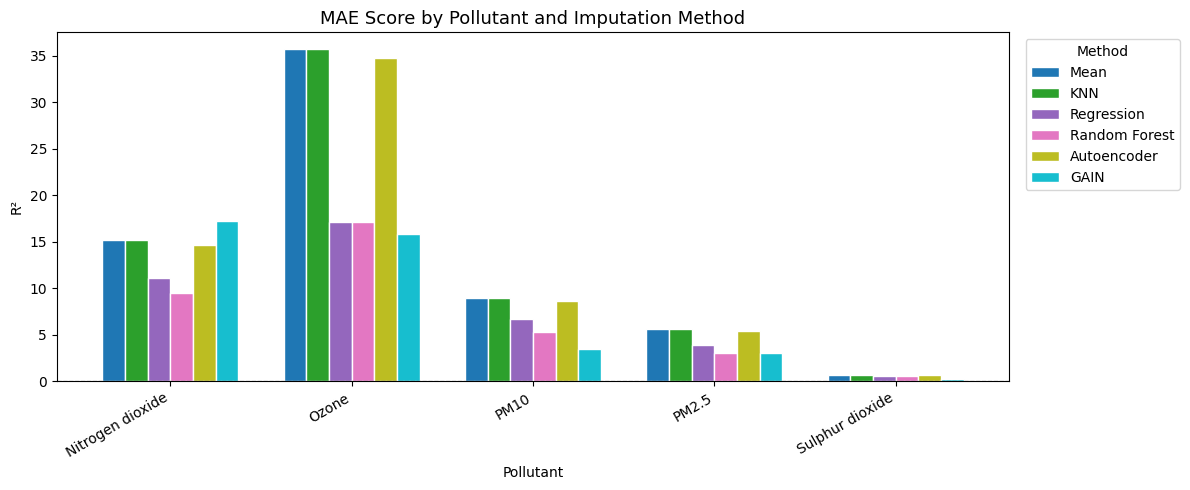

In [38]:
mae_plot = mae_comparison_table.copy()

ax = mae_plot.plot(kind='bar', figsize=(12, 5), width=0.75,
                  colormap='tab10', edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("MAE Score by Pollutant and Imputation Method", fontsize=13)
ax.set_xlabel("Pollutant"); ax.set_ylabel("R²")
ax.set_xticklabels(mae_plot.index, rotation=30, ha='right')
ax.legend(title='Method', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

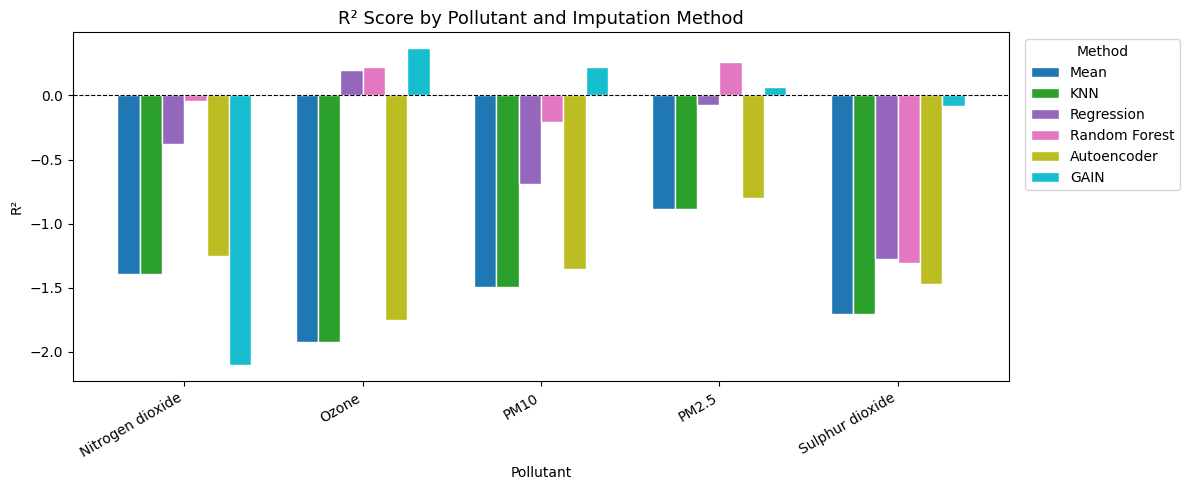

In [39]:
r2_plot = r2_comparison_table.copy()

ax = r2_plot.plot(kind='bar', figsize=(12, 5), width=0.75,
                  colormap='tab10', edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("R² Score by Pollutant and Imputation Method", fontsize=13)
ax.set_xlabel("Pollutant"); ax.set_ylabel("R²")
ax.set_xticklabels(r2_plot.index, rotation=30, ha='right')
ax.legend(title='Method', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 7.3 Time Series Comparison — GAIN vs Original (NO₂)

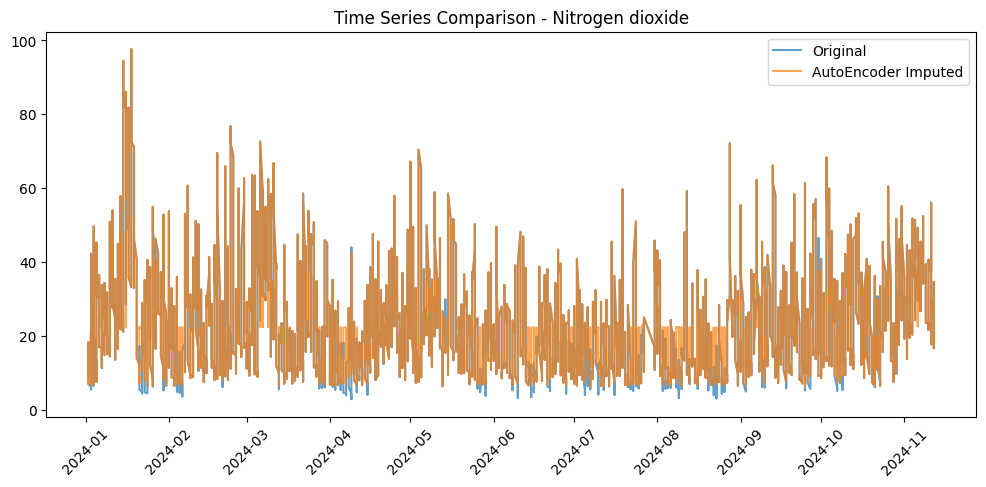

In [40]:
column = data.columns[0]

plt.figure(figsize=(12,5))

plt.plot(df['Date'], data[column], label="Original", alpha=0.7)
plt.plot(df['Date'], gain_imputed[column], label="GAIN Imputed", alpha=0.7)

plt.legend()
plt.title(f"Time Series Comparison - {column}")
plt.xticks(rotation=45)
plt.show()

### 7.4 Zoomed Time Series — Gap Region (NO₂)

Zooms into a 200-row window around an artificially masked region to compare how each method fills the gap.

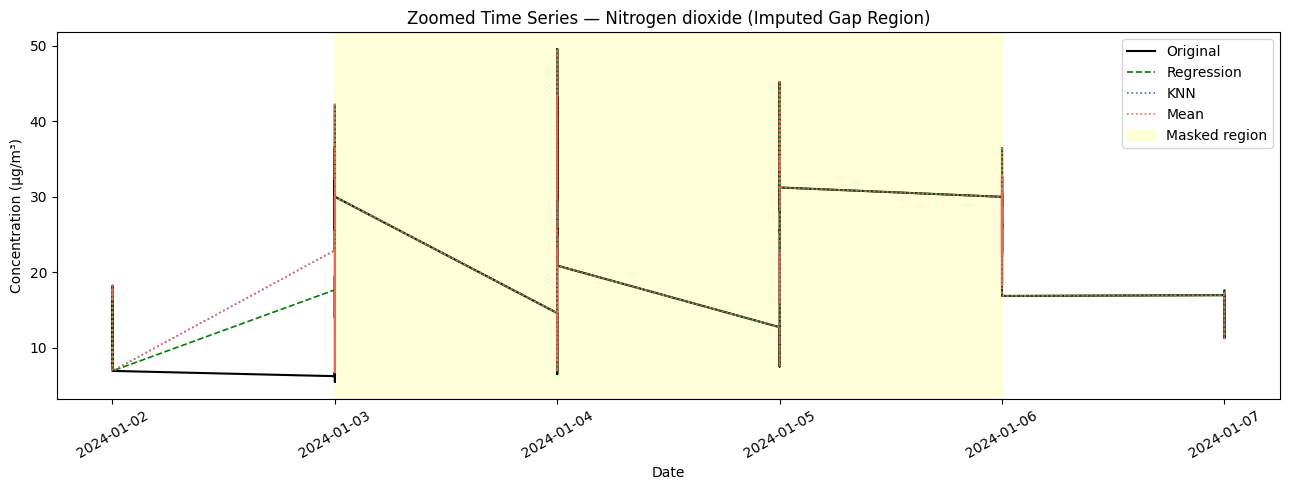

In [41]:
col = "Nitrogen dioxide"
window = 200  # rows around a gap

# Find first gap in the artificial mask
gap_idx = artificial_mask[col][artificial_mask[col]].index[0]
loc = data.index.get_loc(gap_idx)
start = max(0, loc - window//2)
end   = min(len(data), loc + window//2)

idx_range = data.index[start:end]
x = df['Date'].iloc[start:end]

plt.figure(figsize=(13, 5))
plt.plot(x, data[col].iloc[start:end], label='Original', linewidth=1.5, color='black')
plt.plot(x, reg_imputed[col].iloc[start:end], label='Regression', linewidth=1.2, linestyle='--', color='green')
plt.plot(x, knn_imputed[col].iloc[start:end], label='KNN', linewidth=1.2, linestyle=':', color='royalblue')
plt.plot(x, stat_imputed[col].iloc[start:end], label='Mean', linewidth=1.2, linestyle=':', color='tomato')

# Shade the gap region
gap_dates = df['Date'][artificial_mask[col].values].iloc[
    np.where((artificial_mask[col].values.nonzero()[0] >= start) &
             (artificial_mask[col].values.nonzero()[0] < end))[0]]
if len(gap_dates):
    plt.axvspan(gap_dates.iloc[0], gap_dates.iloc[-1], alpha=0.15, color='yellow', label='Masked region')

plt.title(f"Zoomed Time Series — {col} (Imputed Gap Region)", fontsize=12)
plt.xlabel("Date"); plt.ylabel("Concentration (μg/m³)")
plt.legend(); plt.xticks(rotation=30)
plt.tight_layout()
plt.show()